<a href="https://colab.research.google.com/github/vrutansh/CORA/blob/main/cora_citation_network_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Citation Network Paper Classification with Cora

Classifies research papers into one of **seven topics** using both paper-word features and citation relationships.

We compare two approaches:

| Approach |
|---|
| Random Forest baseline |
| Two-layer GCN |

# Dataset: Cora

In this project, we are using a **prebuilt graph dataset called Cora**.

The Cora dataset contains **scientific research papers** and the **citation relationships between those papers**.

---

## How is the dataset represented?

We represent the dataset as a **graph**.

    Research Paper A  ─────►  Research Paper B
            ●                       ●
          Node                    Node



## 1. Install and import packages

In [37]:
%pip install torch torch-geometric scikit-learn pandas matplotlib seaborn networkx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from torch_geometric.datasets import Planetoid
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

## 2. Load the Cora citation graph


  Planetoid is the PyTorch Geometric dataset wrapper for Cora, CiteSeer, and PubMed [4]. Each paper is a node, each citation is an edge, x contains node features, and y contains topic labels. The provided masks define the train, validation, and test nodes.

In [38]:
dataset = Planetoid(root='data/Planetoid', name='Cora')

In [39]:
data = dataset[0]
print(data.num_nodes)
print(data.num_edges)
print(data.num_node_features)
print(dataset.num_classes)


2708
10556
1433
7


## 3. Inspect citation network structure

###### A node degree is the number of edges connected to a paper. Degree is a simple graph feature : highly connected papers maybe more central to their topic, although degree alone is not enough for classification

0    351
1    217
2    418
3    818
4    426
5    298
6    180
Name: count, dtype: int64


<Axes: xlabel='None', ylabel='count'>

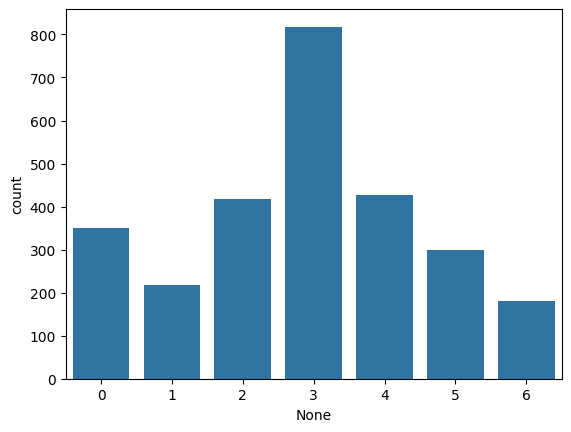

In [40]:
topic_counts = pd.Series(data.y.numpy()).value_counts().sort_index()
print(topic_counts)
sns.barplot(x=topic_counts.index, y=topic_counts)

##4. Baseline: TF-IDF-style features plus Random Forest
The Cora features are binary indicators for whether a vocabulary word appears in a paper. TfidfTransformer reweights these columns so that words occurring in many papers receive less emphasis. We then add two easy graph features: degree and log-degree.

This is a fair educational baseline, but it is not a text model trained on raw abstracts. Its purpose is to answer: How well can we classify papers without message passing across the graph?

In [41]:
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_binary = data.x.numpy()
y = data.y.numpy()
tfidf = TfidfTransformer()
X_tfidf = tfidf.fit_transform(X_binary).toarray()
X_baseline = X_tfidf

train_idx = data.train_mask.numpy()
val_idx = data.val_mask.numpy()
test_idx = data.test_mask.numpy()

X_train , y_train = X_baseline[train_idx], y[train_idx]
X_test , y_test = X_baseline[test_idx], y[test_idx]
X_val , y_val = X_baseline[val_idx], y[val_idx]

rf = RandomForestClassifier(n_estimators=100,max_features="sqrt",class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(accuracy_score(y_test, y_pred))
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

0.58


In [42]:
#Evalutation
from sklearn.metrics import accuracy_score, f1_score,confusion_matrix
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred, average='macro')
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(f"Macro-F1: {f1_score(y_test, rf_pred, average='macro'):.4f}")


Accuracy: 0.5800
Macro-F1: 0.5818


<Axes: >

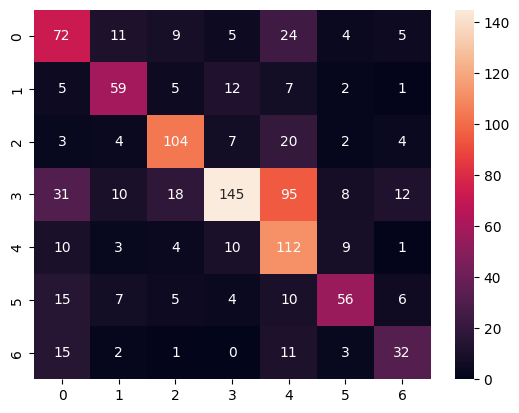

In [43]:
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt="d")

###5. Advanced model: a simple two-layer GCN
A GCN updates each paper by combining its own features with information from neighboring papers. In this notebook, the model has only two graph-convolution layers, a ReLU activation, and dropout. This keeps the code readable while demonstrating the central idea of graph neural networks.

GCNConv is PyTorch Geometric's implementation of the graph convolution operator [5].

In [64]:
import torch.nn.functional as F
from torch import nn
from torch_geometric.nn import GCNConv
import torch

class SimpleGCN(nn.Module):
  def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.5):
    super(SimpleGCN, self).__init__()
    self.conv1 = GCNConv(input_dim, hidden_dim)
    self.conv2 = GCNConv(hidden_dim, output_dim)
    self.dropout = dropout


  def forward(self, x, edge_index):
     x = self.conv1(x, edge_index)
     x = F.relu(x)
     x = F.dropout(x, p=self.dropout, training=self.training)
     x = self.conv2(x, edge_index)
     return x

model = SimpleGCN(
    input_dim=data.num_features,
    hidden_dim=32,
    output_dim=dataset.num_classes

    )
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()
print(model)

SimpleGCN(
  (conv1): GCNConv(1433, 32)
  (conv2): GCNConv(32, 7)
)


In [65]:
# Research Paper A -> 0, 1, 2, 3, 4, 5, 6

In [66]:
#Training of GCN Model
def train_one_epoch():
    model.train() #Training
    optimizer.zero_grad()
    logits = model(data.x, data.edge_index) #x-> 2708 x 7
    loss = F.cross_entropy(logits[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate(mask):
    model.eval()
    logits = model(data.x, data.edge_index) # Pass full edge_index to the model
    predictions = logits.argmax(dim=1)
    accuracy = (predictions[mask] == data.y[mask]).float().mean().item() # Corrected accuracy calculation
    macro_f1 = f1_score(
        data.y[mask].numpy(),
        predictions[mask].numpy(),
        average="macro"
    )
    return accuracy, macro_f1, predictions

In [67]:
# evaluate(data.train_mask)

In [68]:
losses, train_accuracies, val_accuracies = [], [], []
best_val_accuracy = 0.0
best_state = None

epoch_without_improvement = 0
patience = 20 #Stop i no improvement for this many epochs

for epoch in range(1, 201):
  loss = train_one_epoch()
  train_accuracy,_,_ = evaluate(data.train_mask)
  val_accuracy,_,_ = evaluate(data.val_mask)

  losses.append(loss)
  train_accuracies.append(train_accuracy)
  val_accuracies.append(val_accuracy) #0.70

  if val_accuracy > best_val_accuracy: #0.56 > 0.70
    best_val_accuracy = val_accuracy
    best_state = model.state_dict()
    epoch_without_improvement = 0

  else:
    epoch_without_improvement += 1

  if epoch_without_improvement >= patience:
    print(f"Early stopping at epoch {epoch}")
    break

  if epoch == 1 or epoch % 10 == 0:
    print(f"Epoch: {epoch:03d} | Loss: {loss:.4f} | Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f} |Best Val Acc: {best_val_accuracy:.4f}")

model.load_state_dict(best_state)
gcn_accuracy, gcn_f1, gcn_pred = evaluate(data.test_mask)

print(f"\nGCN test accuracy: {gcn_accuracy:.3f}")
print(f"GCN test macro-F1: {gcn_f1:.3f}")

Epoch: 001 | Loss: 1.9535 | Train Acc: 0.8286 | Val Acc: 0.5480 |Best Val Acc: 0.5480
Epoch: 010 | Loss: 0.4140 | Train Acc: 0.9857 | Val Acc: 0.7740 |Best Val Acc: 0.7740
Epoch: 020 | Loss: 0.0768 | Train Acc: 1.0000 | Val Acc: 0.7840 |Best Val Acc: 0.7940
Epoch: 030 | Loss: 0.0238 | Train Acc: 1.0000 | Val Acc: 0.7660 |Best Val Acc: 0.7940
Early stopping at epoch 35

GCN test accuracy: 0.788
GCN test macro-F1: 0.785
